# California Housing Price Prediction

## 1. Proyect Overview

The objective of this project is to develop a Machine Learning model capable of predicting the median house value of California districts based on demographic and housing characteristics.

The project follows a complete Machine Learning workflow including:

- Data exploration
- Data preprocessing
- Feature engineering
- Model training
- Model evaluation
- Model interpretation

## 2. Business Problem

Accurately estimating housing prices is valuable for:

- Real estate agencies
- Property investors
- Financial institutions
- Home buyers

The goal is to estimate the median house value using demographic and geographical variables.

## 3. Model
In this analysis we are using a California Housing Dataset provided by scikit-learn for building a Linear Regression Model.
The dataset contains 20,640 observations (instances) and 8 predictor variables (attributes) describing demographic and housing characteristics of California district.
 The target variable (Price) represents the median house value expressed on thousands of dollars ($100,000).

Attribute Information:

    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

## 4. Data Loading



Importing basic libraries:

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from traitlets import observe
%matplotlib inline

Loading the dataset from sklearn.datasets and asigning it to a Pandas DataFrame:


In [6]:
    from sklearn.datasets import fetch_california_housing
    CA = fetch_california_housing()
    df = pd.DataFrame(CA.data, columns=CA.feature_names)
    df['Price'] = CA.target

## 5. Exploratory Data Analysis (EDA)

Before training any predictive model, it is important to understand the structure, quality, and statistical properties of the dataset. This section explores the main characteristics of the California Housing dataset.

In [7]:
print(CA.keys())
print(CA.feature_names)
print(CA.target_names)
print(CA.DESCR)

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
['MedHouseVal']
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The tar

Checking the first records and a general description of the Data Frame:

In [8]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 6. Data Visualization


Lets visualize our data set for a better interpretation:

### 6.1 Correlation Analysis
 - A heat map for the correlation matrix is useful for easily identifying any important connection between two variables. Correlation analysis provides an initial understanding of the linear relationships between variables and helps identify which features are most strongly associated with housing prices.

<Axes: >

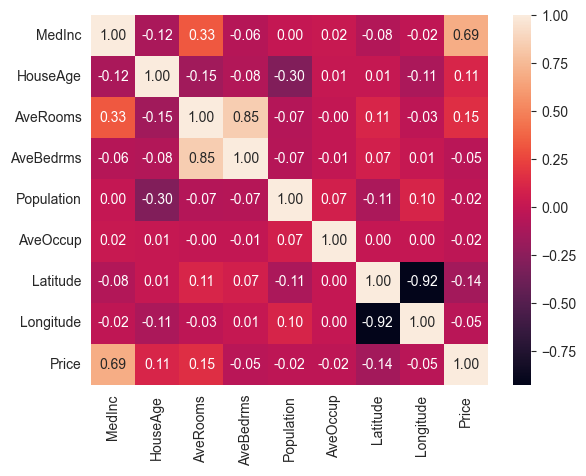

In [9]:
sns.heatmap(df.corr(), annot=True,  fmt=".2f")

### 6.2 Distribution between Atributes
  - A pair plot is useful for cheking distribution between variables by pair. Visualizing feature distributions helps identify skewness, potential outliers, and differences in variable scales that may require preprocessing before model training.

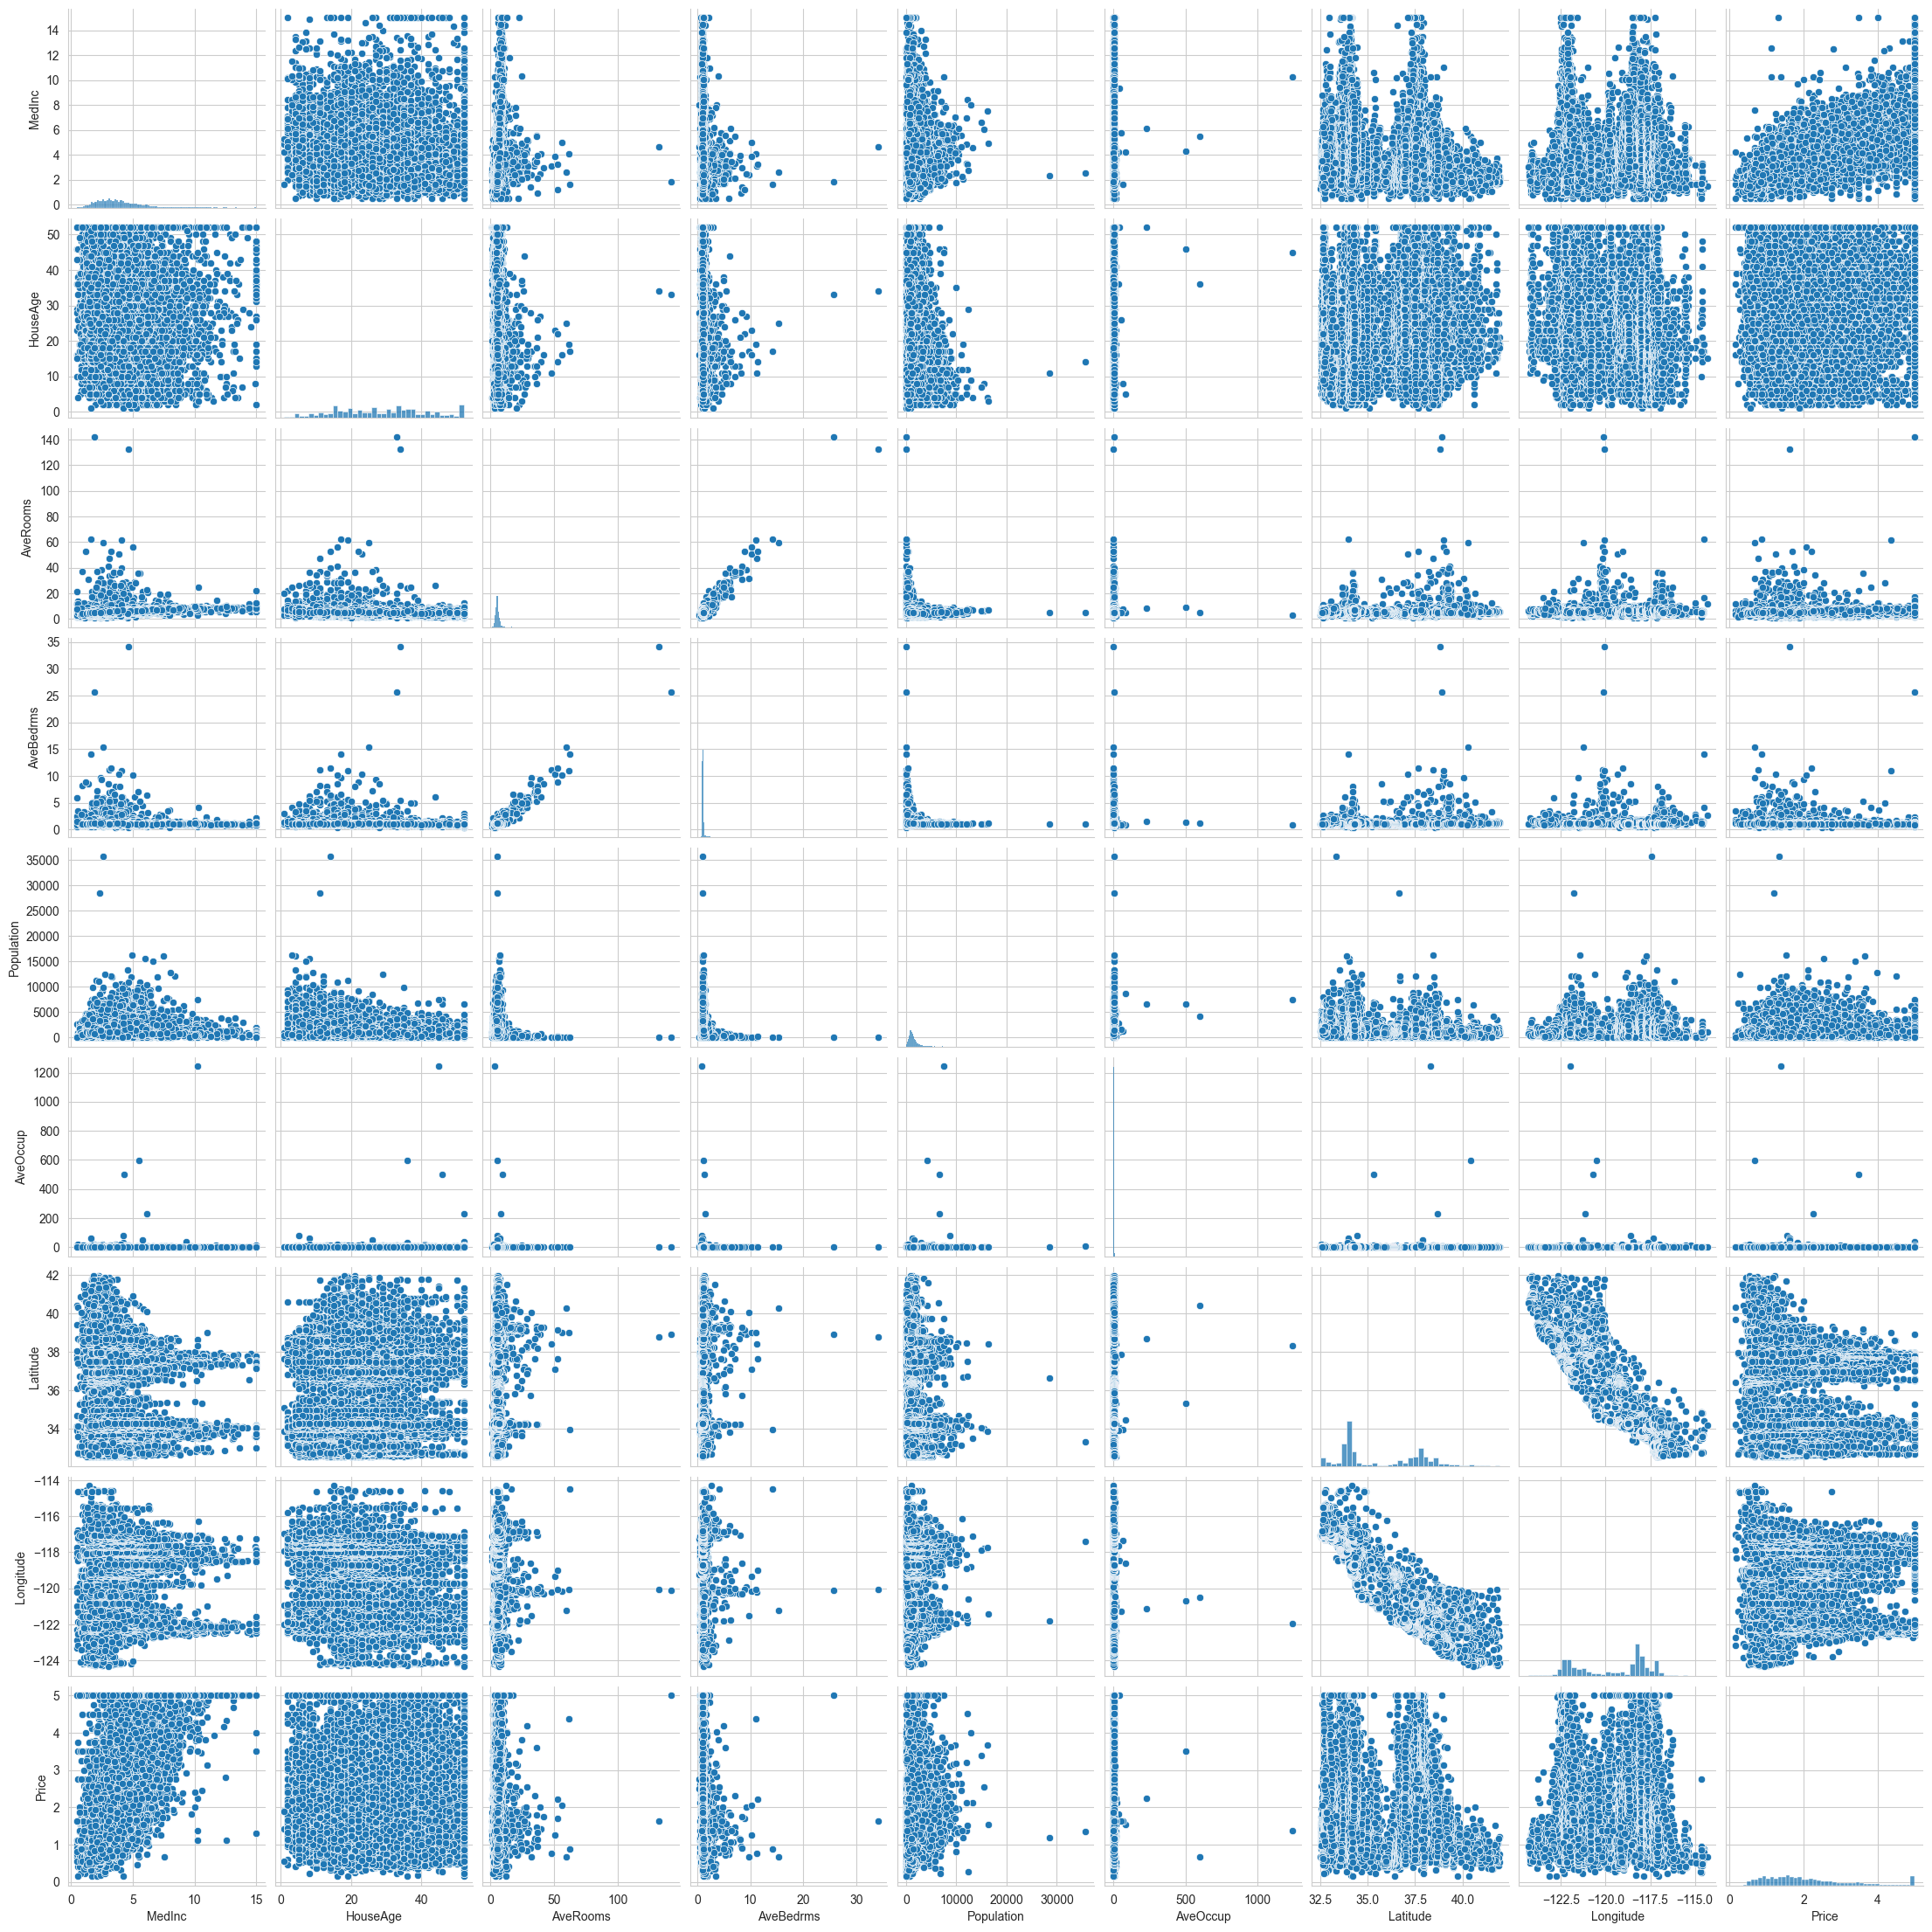

In [13]:
sns.pairplot(df)

### 6.3 Distribution of Target Variable
We are as well using a displot for cheking the count distribution of our target variable "Price".

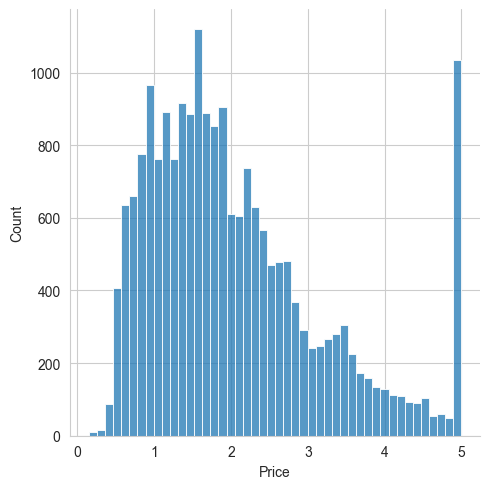

In [54]:
sns.displot(df['Price'])

#### Important Observation

The histogram reveals that the target variable (`Price`) is **right-censored**. House values above approximately **$500,000** are capped at a value of **5.0**, producing an artificial concentration of observations at the upper limit. This may affect the performance of a Linear Regression model because the target variable no longer represents the true distribution of house prices.

To evaluate the impact of this censoring on model performance, we first train a **Baseline Linear Regression model** using the complete original dataset. Next, we remove the censored observations (`Price = 5.0`) and train a second model using the filtered dataset. Finally, both models are compared to determine whether removing the censored values improves predictive performance.


## 7. Baseline Linear Regression Model

Before applying any preprocessing techniques, a **Baseline Linear Regression model** is trained using the original dataset. This first model serves as a reference point for evaluating whether data preprocessing improves predictive performance.

We start defining our dataframe of independent atributes corresponding to **X** and asigning dependant variable `Price` to **Y** vector.

In [10]:
df.columns
# Independant variables
X=df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup','Latitude', 'Longitude']]
# Dependant Variables
Y=df['Price']

### 7.1 Train-Test Split

To obtain an unbiased evaluation of the model, the dataset is randomly divided into a **training set (60%)** and a **testing set (40%)**.

The training set is used to estimate the parameters of the Linear Regression model, while the testing set is reserved exclusively for performance evaluation. Keeping the testing data separate allows the model to be assessed on observations that were not used during training, providing a more reliable estimate of its predictive capability.

A fixed `random_state` is used to guarantee reproducibility of the results.

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=101)


### 7.2 Model Training

Once the dataset has been divided into training and testing subsets, the next step is to train a **Linear Regression model** using the training data.

During this process, the tool `class sklearn.linear_model.LinearRegression()` is an algorithm that estimates the intercept and the regression coefficients that best describe the relationship between the predictor variables and the target variable by minimizing the residual sum of squares.

After fitting the model, we examine the estimated coefficients to understand how each predictor contributes to the predicted house price.

In [12]:
# Creating linear model
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train, Y_train)

lm.intercept_, lm.coef_


(np.float64(-35.31110661718541),
 array([ 4.30863349e-01,  1.02352181e-02, -1.04016683e-01,  5.37428718e-01,
         1.80375787e-05, -1.47742974e-01, -4.19256479e-01, -4.24321036e-01]))

### 7.3 Model Coefficients
The table below shows the obtained coefficients from the **Linear Regression Model**

In [14]:

coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
MedInc,0.430863
HouseAge,0.010235
AveRooms,-0.104017
AveBedrms,0.537429
Population,0.000018
AveOccup,-0.147743
Latitude,-0.419256
Longitude,-0.424321


#### Linear Regression Equation

The fitted model can be expressed as a linear equation, where the predicted house price is calculated as the intercept plus the weighted contribution of each predictor variable.

The estimated coefficients obtained above define the final regression equation:
$$ y= -35.31 + 0.43x_1 +.0102 x_2 -0.104x_3 +0.537x_4 + 0.000018x_5 -0.147x_6 -0.419x_7 -0.424x_8$$

### 7.4 Model Evaluation

After fitting the Linear Regression model, the next step is to evaluate its predictive performance on data that were not used during training, by using the test variables that we split from the beginning.

Predictions are generated using the **X_test** dataset and compared with the corresponding **Y_test** values. If the model performs well, the predicted values should closely match the actual observations. In a scatter plot of actual versus predicted values, this relationship is expected to appear as a positive linear trend, with most observations concentrated around the diagonal.



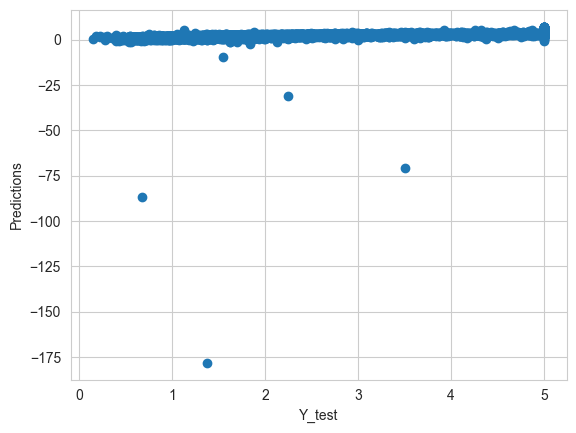

In [17]:
predictions = lm.predict(X_test)
plt.scatter(Y_test, predictions)
plt.xlabel("Y_test")
plt.ylabel("Predictions")
plt.show()

#### Interpretation

The scatter plot does not show the expected linear relationship between the predicted and actual values. Instead of forming a narrow diagonal band, the observations appear widely dispersed, indicating that the model struggles to accurately predict housing prices.

This suggests that the Linear Regression model is not capturing the underlying relationship present in the original dataset. One possible explanation is the presence of the right-censored target variable, which limits the model's ability to learn the true distribution of house prices.

### 7.5 Residual Analysis

Residual analysis is an important diagnostic step for Linear Regression models. The residuals represent the difference between the actual and predicted values.

A well-fitted Linear Regression model is expected to produce residuals that are approximately normally distributed and centered around zero. Significant deviations from this pattern may indicate that some of the model assumptions are not satisfied.
We are going to check the distribution of the residuals between them to prove if they are normally distributed.

(-10.0, 10.0)

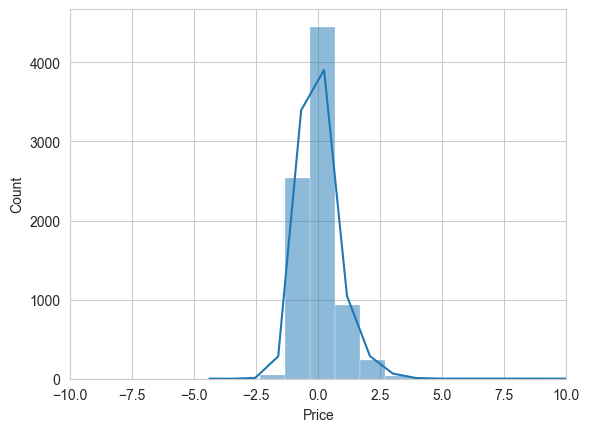

In [19]:
sns.histplot((Y_test-predictions), kde=True, );
plt.xlim(-10,10)


#### Interpretation

The residuals do not appear to follow a normal distribution. Instead, the distribution is noticeably skewed and influenced by several extreme errors.

These results support the findings from the scatter plot and suggest that the original dataset does not satisfy the assumptions required for an effective Linear Regression model. This motivates building a second model after removing the right-censored observations.

### 7.6 Regression Evaluation Metrics

To quantitatively evaluate the model performance, we compute three standard regression metrics:

- **Mean Absolute Error (MAE):** measures the average absolute difference between the predicted and actual values.
- **Mean Squared Error (MSE):** penalizes larger prediction errors by squaring the residuals.
- **Root Mean Squared Error (RMSE):** expresses the prediction error in the same units as the target variable, making it easily comparable.

Lower values for these metrics indicate better predictive performance.

In [16]:
from sklearn import metrics

MAE1=metrics.mean_absolute_error(Y_test, predictions)
MSE1=metrics.mean_squared_error(Y_test, predictions)
RMSE1=np.sqrt(metrics.mean_squared_error(Y_test, predictions))
print('MAE:', MAE1)
print('MSE:', MSE1)
print('RMSE:', RMSE1)

MAE: 0.5620561497050929
MSE: 6.160634987005654
RMSE: 2.4820626476794767


#### Interpretation

The evaluation metrics confirm the poor predictive performance observed in the previous visualizations. The relatively high MAE indicates that, on average, the predicted house prices differ considerably from the actual values.

In the same way, the large MSE and RMSE reveal the presence of substantial prediction errors, particularly for observations with higher residuals. These results are consistent with the scatter plot and residual analysis, suggesting that the Linear Regression model is unable to represent the original dataset.

Main reason that the model does not achieve the expected predictive performance might be due to the right-censoring of the target variable, which compresses all house prices above the upper limit into the same value. In the next section, we repeat the same workflow using a cleaned version of the dataset by removing these censored observations, expecting a better fit for the new

Overall, the model does not achieve the expected predictive performance. In the next section, we repeat the same workflow using a cleaned version of the dataset and compare the results.
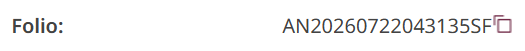

## 8. Cleaned Dataset Linear Model

### 8.1 Data Cleaning
The results above  indicates that removing records from `Price` higher than **$500,000** is necessary in order to fit better a Linear Model. We adjust our new data frame as it folows:


In [20]:
df_clean = df[df['Price'] < 5]


### Dataset Comparison

Before aplying the algorithm to the new Dataset, it´s convinient to compare the general description with the original one.

In [22]:
# Original Dataset
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [21]:
# New Dataset
df_clean.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000
mean,3.676411,28.373066,5.361708,1.096621,1441.368485,3.096560,35.651872,-119.562378,1.920553
std,1.570602,12.504050,2.293321,0.452136,1144.075196,10.639195,2.150066,2.005760,0.971109
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.526300,18.000000,4.416667,1.005882,796.000000,2.446614,33.930000,-121.760000,1.164750
50%,3.449050,28.000000,5.185730,1.048576,1179.000000,2.837779,34.270000,-118.500000,1.736000
75%,4.582500,37.000000,5.971083,1.099222,1746.250000,3.306021,37.730000,-117.990000,2.479000
max,15.000100,52.000000,132.533333,34.066667,35682.000000,1243.333333,41.950000,-114.310000,4.991000


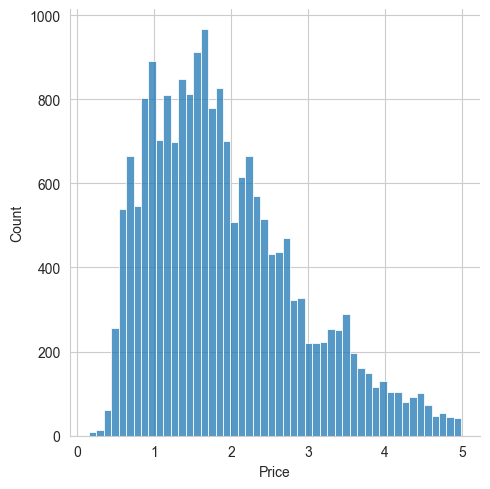

In [23]:
sns.displot(df_clean['Price'])


#### Interpretation

Main differences between both datasets:

- 992 observations were removed after excluding the right-censored target values.
- The average house price decreased from **2.07** to **1.92**, reflecting the removal of the highest-priced districts.
- The standard deviation also decreased from **1.15** to **0.97**, indicating lower variability in the target variable.
- The overall feature distributions remained very similar, suggesting that the trimming process mainly affected the upper tail of the target variable rather than the general structure of the dataset.
- By removing the censored observations, the model can be trained on data that better represents the true relationship between the predictor variables and housing prices.
- The `Price` histogram shows no anormal concentration of records on the right.

## 8.3 Model Development
To evaluate the effect of removing the right-censored observations, the same modeling procedure used for the original dataset is repeated:
- Define independent predictor **X** variables and dependand **Y** target variable
- Split the data sample into training and testing sets using the same random seed ands train-test proportion to make it comparable to previous model.
- Use the  `class sklearn.linear_model.LinearRegression()` to estimate the intercept and the regression coefficients that best describe the relationship between the predictor variables and the target variable by minimizing the residual sum of squares.


In [20]:
# Define X and Y variables
df_clean.columns
X = df_clean[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
        'Latitude', 'Longitude']]
Y = df_clean['Price']


# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=101)

# Creating linear model
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train, Y_train)

lm.intercept_, lm.coef_


(np.float64(-34.84364152460196),
 array([ 4.29269581e-01,  8.37466900e-03, -1.06997833e-01,  6.65447704e-01,
         3.50698909e-06, -3.41592716e-03, -3.91626450e-01, -4.07811668e-01]))

## 8.4 Model Coefficients
The new coefficient estimates are shown on the table below:

In [21]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
MedInc,0.429270
HouseAge,0.008375
AveRooms,-0.106998
AveBedrms,0.665448
Population,0.000004
AveOccup,-0.003416
Latitude,-0.391626
Longitude,-0.407812


The coefficient estimates remain relatively consistent with those obtained from the original dataset, suggesting that the relationship between the predictors and housing prices is preserved after removing the censored observations.

#### Linear Regression Equation
Now that we have our new values for the intercept and the coefficients, our **Linear Regression Model equation**  is:
$$ y= -34.84 + 0.429x_1 +.0083 x_2 -0.106x_3 +0.665x_4 + 0.000004x_5 -0.003x_6 -0.391x_7 -0.407x_8$$


### 8.5 Model Evaluation

After fitting the Linear Regression model using the cleaned dataset, the next step is to evaluate its predictive performance.

To ensure a fair comparison with the original model, the same evaluation procedure is followed. The assessment includes three complementary analyses:

- Comparison between actual and predicted values.
- Residual analysis.
- Regression evaluation metrics.

Together, these techniques provide both a visual and quantitative assessment of the model's performance.

#### Actual vs Predicted Values

The model predictions generated from the **X_test** dataset are compared with the corresponding **Y_test** values using a scatter plot.

Compared with the original model, we expected to produce a positive linear trend where observations lie close to the main diagonal, indicating that the predicted values closely match the actual house prices.


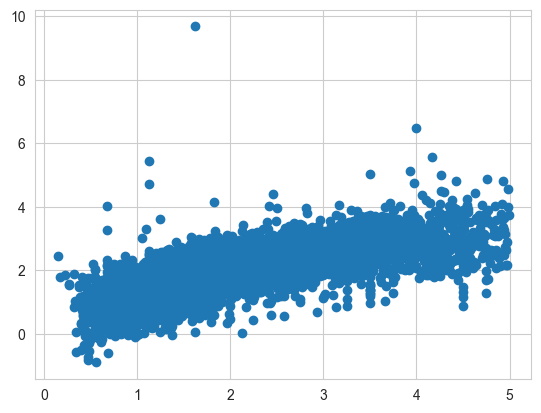

In [23]:
predictions = lm.predict(X_test)
plt.scatter(Y_test, predictions)


#### Residual Analysis
We evaluate Residuals, expecting that this new model produce an aproximately normally distributed behaviour centered around zero. Histogram is shown bellow:


(-10.0, 10.0)

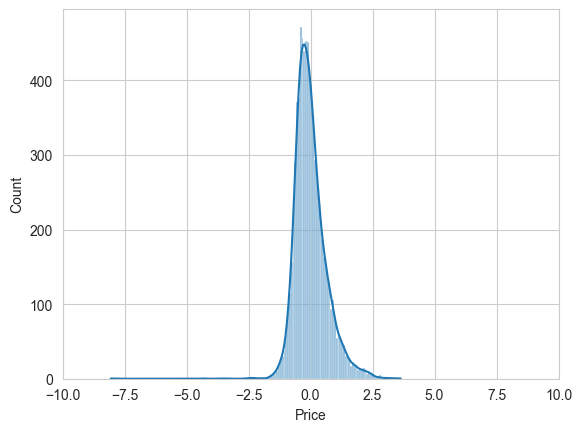

In [24]:

sns.histplot((Y_test - predictions), kde=True, );
plt.xlim(-10, 10)

#### Regression Evaluation Metrics
To quantitatively assess the predictive performance of the cleaned Linear Regression model, we also compute the three standard regression metrics **MAE, MSE** and **RMSE**

We expect lower values for these metrics indicate better model performance in constrast to original dataset model.



In [25]:
MAE2=metrics.mean_absolute_error(Y_test, predictions)
MSE2=metrics.mean_squared_error(Y_test, predictions)
RMSE2=np.sqrt(metrics.mean_squared_error(Y_test, predictions))
print('MAE:', MAE2)
print('MSE:', MSE2)
print('RMSE:', RMSE2)

MAE: 0.4765509597640189
MSE: 0.41145534861859556
RMSE: 0.6414478533899662


#### Overall Evaluation

Compared with the original model, all three evaluation metrics decreased substantially after removing the right-censored observations.

The scatter plot shows a stronger agreement between predicted and actual values, the residuals are more symmetrically distributed, and all regression error metrics decrease substantially: the lower MAE indicates that the average prediction error is smaller, while the reductions in MSE and RMSE show that large prediction errors became considerably less frequent.

These results demonstrate the positive impact of removing the right-censored observations before training the model.

Overall, the cleaned dataset allows the Linear Regression model to achieve a more accurate and reliable representation of California housing prices.




## COMPARISON


As we can observe on the table below, when we clean our data taking away the right censored values bigger than 5, we can build a better model that predicts closer tho our testing values.

In [27]:

results = pd.DataFrame({
    'Original data': [MAE1, MSE1, RMSE1],
    'Clean data': [MAE2, MSE2, RMSE2]
}, index=['MAE', 'MSE', 'RMSE'])

results


,Original data,Clean data
MAE,0.562056,0.476551
MSE,6.160635,0.411455
RMSE,2.482063,0.641448
